### RESULTS
Cargaremos el rendimiento de los modelos entrenados y generaremos tablas y figuras comparativas entre los distintos modelos.

In [2]:
# Importaciones
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Carga de los resultados

Datos cargados correctamente.
Tabla Comparativa de Modelos [cite: 31]


,Modelo,Top-1 Accuracy,Top-5 Accuracy,Ruta Pesos
0,yolov8m-cls,0.7000,1.0000,runs/classify\train_yolov8m-cls\weights\best.pt
1,yolov8n-cls,0.6625,0.9625,runs/classify\train_yolov8n-cls\weights\best.pt
2,yolov8s-cls,0.7250,0.9625,runs/classify\train_yolov8s-cls\weights\best.pt


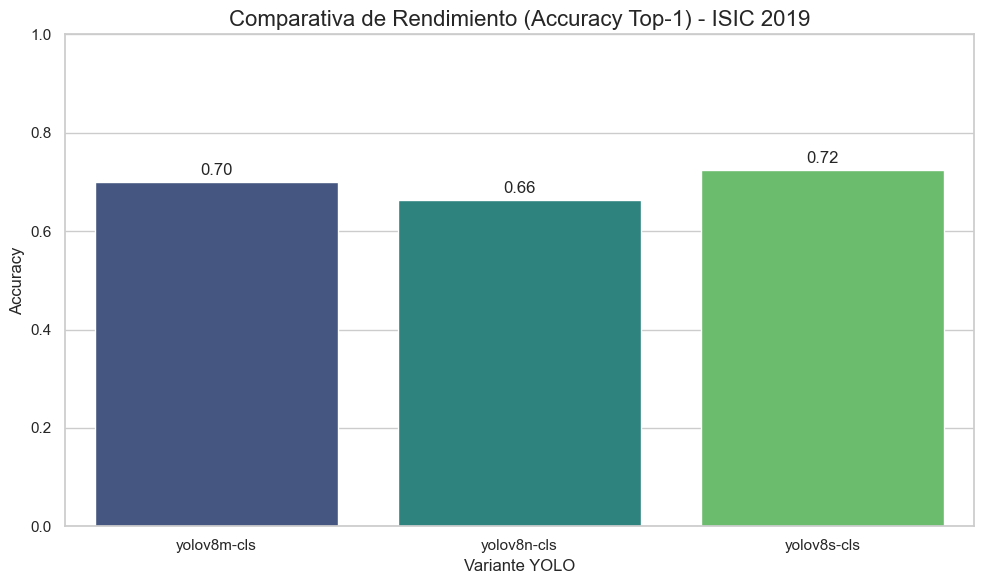

In [4]:
# Cargar métricas generadas
csv_path = "evaluacion_metricas.csv"
if not os.path.exists(csv_path):
    print(f"Error: No se encuentra {csv_path}. Ejecuta eval.ipynb primero.")
else:
    df = pd.read_csv(csv_path)
    print("Datos cargados correctamente.")

# Mostrar tabla formateada (con fallback si no hay IPython)
print("Tabla Comparativa de Modelos [cite: 31]")
try:
    from IPython.display import display as _display
    _display(df)
except Exception:
    print(df.to_string(index=False))

# Verificar columnas esperadas
expected_cols = ['Modelo', 'Top-1 Accuracy']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    print(f"Columnas faltantes en CSV: {missing}. Columnas disponibles: {list(df.columns)}")
else:
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    barplot = sns.barplot(
        data=df,
        x='Modelo',
        y='Top-1 Accuracy',
        hue='Modelo',
        palette='viridis'
    )
    plt.title('Comparativa de Rendimiento (Accuracy Top-1) - ISIC 2019', fontsize=16)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Variante YOLO', fontsize=12)
    plt.ylim(0, 1.0)
    for container in barplot.containers:
        barplot.bar_label(container, fmt='%.2f', padding=3)
    plt.tight_layout()
    plt.savefig('comparativa_accuracy.png')
    plt.show()